Taken from : https://medium.com/@fernandopalominocobo/mastering-u-net-a-step-by-step-guide-to-segmentation-from-scratch-with-pytorch-6a17c5916114

 Segmentation is the process of dividing an image into multiple segments or regions to simplify its representation and make it easier to analyze.

U-Net is a convolutional neural network (CNN) architecture that was specifically designed for biomedical image segmentation tasks.

## Architecture
The U-Net architecture is characterized by its U-shaped structure, which gives it its name. It consists of an encoding path and a decoding path.

- Encoding Path: This part of the network captures the context of the input image by using a series of convolutional and max-pooling layers to downsample the spatial dimensions. It “contracs” the original images.

- Decoding Path: The decoding path uses upsampling and convolutional layers to produce a segmentation map that has the same spatial dimensions as the input image. It “expands” the contracted images.

U-Net’s strength in segmentation comes from its use of skip connections, (grey arrows in the Figure 1) which connect the encoding and decoding paths by merging features. This helps retain spatial details lost during downsampling, preserving the image’s local and global context. By maintaining this spatial information, U-Net achieves more accurate segmentation masks. The skip connections assist the network in grasping the relationships between image parts, leading to improved segmentation results.

## IMPLEMENTATION

In [1]:
import copy
import os
import random
import shutil
import zipfile
from math import atan2, cos, sin, sqrt, pi, log

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from PIL import Image
from numpy import linalg as LA
from torch import optim, nn
from torch.utils.data import DataLoader, random_split
from torch.utils.data.dataset import Dataset
from torchvision import transforms
from tqdm import tqdm

In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        '''
        in_channels: Number of channels in the input image (e.g., 3 for RGB).

        num_classes: Number of classes for segmentation (output channels).
        '''
        super().__init__()
        self.conv_op = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv_op(x)

In [4]:
class DownSample(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = DoubleConv(in_channels, out_channels)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        down = self.conv(x)
        p = self.pool(down)

        return down, p

U-Net architecture includes skip connections which allow for the fusion of low-level and high-level features, aiding in better localization. In this downsampling part of the architecture, before doing the MaxPooling, we save the convolutioned tensor. That convolutioned tensor is later on concatenated with an upsampled tensor with its own dimension. In the code, this can be seen that the createdDownSample class return two variables down and p.



In [5]:
class UpSample(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels//2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        x = torch.cat([x1, x2], 1)
        return self.conv(x)

In [ ]:
class UNet(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()
        '''
        Applies DoubleConv to the input (e.g., RGB → 64 feature maps).

        Followed by pooling to reduce spatial size (e.g., 256×256 → 128×128).'''
        # Each DownSample block doubles the number of channels and halves the spatial resolution using MaxPool2d.
        self.down_convolution_1 = DownSample(in_channels, 64)
        self.down_convolution_2 = DownSample(64, 128)
        self.down_convolution_3 = DownSample(128, 256)
        self.down_convolution_4 = DownSample(256, 512)

        '''
        Applies two 3x3 convolutions with ReLU without downsampling.

Extracts deep features from the most compressed representation.
        '''
        self.bottle_neck = DoubleConv(512, 1024)

        # Upsamples 1024 → 512 channels (usually via ConvTranspose2d or bilinear upsampling).
        # Concatenates with down_4 skip connection (from encoder).

        # Applies DoubleConv.
        self.up_convolution_1 = UpSample(1024, 512)
        # Upsamples 512 → 256 channels, concatenates with down_3 skip connection.
        self.up_convolution_2 = UpSample(512, 256)
        # Upsamples 256 → 128 channels, concatenates with down_2 skip connection.
        self.up_convolution_3 = UpSample(256, 128)
        # Upsamples 128 → 64 channels, concatenates with down_1 skip connection.
        self.up_convolution_4 = UpSample(128, 64)

        # Final 1x1 convolution to reduce channels to num_classes (e.g., 2 for binary segmentation).1x1 convolution to reduce 64 channels to num_classes channels.

        # Outputs per-pixel class scores for segmentation.
        self.out = nn.Conv2d(in_channels=64, out_channels=num_classes, kernel_size=1)

    def forward(self, x):
        # down_1: output before pooling (used as skip connection).
        # p1: pooled version, passed to the next layer.
        down_1, p1 = self.down_convolution_1(x)
        down_2, p2 = self.down_convolution_2(p1)
        down_3, p3 = self.down_convolution_3(p2)
        down_4, p4 = self.down_convolution_4(p3)

    # Processes the deepest features without any pooling or upsampling.
        b = self.bottle_neck(p4)



        '''
        b is upsampled.

        Concatenated with down_4 (from encoder).

        Passed through DoubleConv.
        '''
        up_1 = self.up_convolution_1(b, down_4)
        up_2 = self.up_convolution_2(up_1, down_3)
        up_3 = self.up_convolution_3(up_2, down_2)
        up_4 = self.up_convolution_4(up_3, down_1) #Gradually restores spatial resolution and reduces channels. 

        out = self.out(up_4)  #Converts 64-channel feature map to num_classes output channels.
        return out # Output shape: (batch_size, num_classes, height, width) for segmentation.

In [ ]:
input_image = torch.rand((1,3,512,512)) # Example input image with batch size 1, 3 channels (RGB), and 512x512 resolution.
model = UNet(3,10) # Initialize the model with 3 input channels and 10 output classes.
output = model(input_image)
print(output.size()) # Output size should be (1, 10, 512, 512) for segmentation with 10 classes.

torch.Size([1, 10, 512, 512])


output: for each pixel in the 512×512 image, the model outputs a vector of 10 class scores.

In [8]:
class CarvanaDataset(Dataset):
    def __init__(self, root_path, limit=None):
        self.root_path = root_path
        self.limit = limit
        self.images = sorted([root_path + "/train/" + i for i in os.listdir(root_path + "/train/")])[:self.limit]
        self.masks = sorted([root_path + "/train_masks/" + i for i in os.listdir(root_path + "/train_masks/")])[:self.limit]

        self.transform = transforms.Compose([
            transforms.Resize((512, 512)),
            transforms.ToTensor()])

        if self.limit is None:
            self.limit = len(self.images)

    def __getitem__(self, index):
        img = Image.open(self.images[index]).convert("RGB")
        mask = Image.open(self.masks[index]).convert("L")

        return self.transform(img), self.transform(mask)

    def __len__(self):
        return min(len(self.images), self.limit)

In [9]:
print(os.listdir("../input/carvana-image-masking-challenge/"))

DATASET_DIR = '../input/carvana-image-masking-challenge/'
WORKING_DIR = '/kaggle/working/'

['train_masks.zip', '29bb3ece3180_11.jpg', 'train_masks.csv.zip', 'train.zip', 'metadata.csv.zip', 'sample_submission.csv.zip', 'test.zip', 'test_hq.zip', 'train_hq.zip']


In [10]:
if len(os.listdir(WORKING_DIR)) <= 1:

    with zipfile.ZipFile(DATASET_DIR + 'train.zip', 'r') as zip_file:
        zip_file.extractall(WORKING_DIR)

    with zipfile.ZipFile(DATASET_DIR + 'train_masks.zip', 'r') as zip_file:
        zip_file.extractall(WORKING_DIR)
    
    print(
        len(os.listdir(WORKING_DIR + 'train')),
        len(os.listdir(WORKING_DIR + 'train_masks'))
    )

5088 5088


In [11]:
train_dataset = CarvanaDataset(WORKING_DIR)

generator = torch.Generator().manual_seed(25)

In [12]:
train_dataset, test_dataset = random_split(train_dataset, [0.8, 0.2], generator=generator)

In [13]:
test_dataset, val_dataset = random_split(test_dataset, [0.5, 0.5], generator=generator)


In [14]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
if device == "cuda":
    num_workers = torch.cuda.device_count() * 4

cuda


In [ ]:
LEARNING_RATE = 3e-4
BATCH_SIZE = 8

train_dataloader = DataLoader(dataset=train_dataset,
                              num_workers=num_workers, pin_memory=False,
                              batch_size=BATCH_SIZE,
                              shuffle=True)
val_dataloader = DataLoader(dataset=val_dataset,
                            num_workers=num_workers, pin_memory=False,
                            batch_size=BATCH_SIZE,
                            shuffle=True)

test_dataloader = DataLoader(dataset=test_dataset,
                            num_workers=num_workers, pin_memory=False,
                            batch_size=BATCH_SIZE,
                            shuffle=True)

model = UNet(in_channels=3, num_classes=1).to(device)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


The DICE metric provides a measure of the similarity between two sets, in this case, the predicted segmentation and the ground truth segmentation. It calculates the overlap between the two sets, taking into account both the false positives and false negatives.

And can be understood as:
Dice score = 2 * (number of common elements) / (number of elements in set A + number of elements in set B)

The DICE coefficient ranges from 0 to 1, where a value closer to 1 indicates a higher degree of overlap and thus better segmentation performance. A DICE score of 1 would mean a perfect overlap between the predicted and ground truth segmentations, while a score of 0 would indicate no overlap at all.

In [16]:
def dice_coefficient(prediction, target, epsilon=1e-07):
    prediction_copy = prediction.clone()

    prediction_copy[prediction_copy < 0] = 0
    prediction_copy[prediction_copy > 0] = 1

    intersection = abs(torch.sum(prediction_copy * target))
    union = abs(torch.sum(prediction_copy) + torch.sum(target))
    dice = (2. * intersection + epsilon) / (union + epsilon)
    
    return dice

In [17]:
EPOCHS = 5

train_losses = []
train_dcs = []
val_losses = []
val_dcs = []

for epoch in tqdm(range(EPOCHS)):
    model.train()
    train_running_loss = 0
    train_running_dc = 0
    
    for idx, img_mask in enumerate(tqdm(train_dataloader, position=0, leave=True)):
        img = img_mask[0].float().to(device)
        mask = img_mask[1].float().to(device)
        
        y_pred = model(img)
        optimizer.zero_grad()
        
        dc = dice_coefficient(y_pred, mask)
        loss = criterion(y_pred, mask)
        
        train_running_loss += loss.item()
        train_running_dc += dc.item()

        loss.backward()
        optimizer.step()

    train_loss = train_running_loss / (idx + 1)
    train_dc = train_running_dc / (idx + 1)
    
    train_losses.append(train_loss)
    train_dcs.append(train_dc)

    model.eval()
    val_running_loss = 0
    val_running_dc = 0
    
    with torch.no_grad():
        for idx, img_mask in enumerate(tqdm(val_dataloader, position=0, leave=True)):
            img = img_mask[0].float().to(device)
            mask = img_mask[1].float().to(device)

            y_pred = model(img)
            loss = criterion(y_pred, mask)
            dc = dice_coefficient(y_pred, mask)
            
            val_running_loss += loss.item()
            val_running_dc += dc.item()

        val_loss = val_running_loss / (idx + 1)
        val_dc = val_running_dc / (idx + 1)
    
    val_losses.append(val_loss)
    val_dcs.append(val_dc)

    print("-" * 30)
    print(f"Training Loss EPOCH {epoch + 1}: {train_loss:.4f}")
    print(f"Training DICE EPOCH {epoch + 1}: {train_dc:.4f}")
    print("\n")
    print(f"Validation Loss EPOCH {epoch + 1}: {val_loss:.4f}")
    print(f"Validation DICE EPOCH {epoch + 1}: {val_dc:.4f}")
    print("-" * 30)

# Saving the model
torch.save(model.state_dict(), 'my_checkpoint.pth')

 20%|██        | 1/5 [15:03<1:00:12, 903.25s/it]

------------------------------
Training Loss EPOCH 1: 0.1310
Training DICE EPOCH 1: 0.8372


Validation Loss EPOCH 1: 0.0301
Validation DICE EPOCH 1: 0.9719
------------------------------


 40%|████      | 2/5 [30:03<45:05, 901.67s/it]  

------------------------------
Training Loss EPOCH 2: 0.0416
Training DICE EPOCH 2: 0.9616


Validation Loss EPOCH 2: 0.0205
Validation DICE EPOCH 2: 0.9811
------------------------------


 60%|██████    | 3/5 [45:04<30:02, 901.21s/it]

------------------------------
Training Loss EPOCH 3: 0.0168
Training DICE EPOCH 3: 0.9846


Validation Loss EPOCH 3: 0.0143
Validation DICE EPOCH 3: 0.9871
------------------------------


 80%|████████  | 4/5 [1:00:04<15:00, 900.77s/it]

------------------------------
Training Loss EPOCH 4: 0.0272
Training DICE EPOCH 4: 0.9722


Validation Loss EPOCH 4: 0.1106
Validation DICE EPOCH 4: 0.9003
------------------------------


100%|██████████| 5/5 [1:14:59<00:00, 899.82s/it]


------------------------------
Training Loss EPOCH 5: 0.0278
Training DICE EPOCH 5: 0.9746


Validation Loss EPOCH 5: 0.0136
Validation DICE EPOCH 5: 0.9873
------------------------------


/tmp/ipykernel_35/3950988869.py:27: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


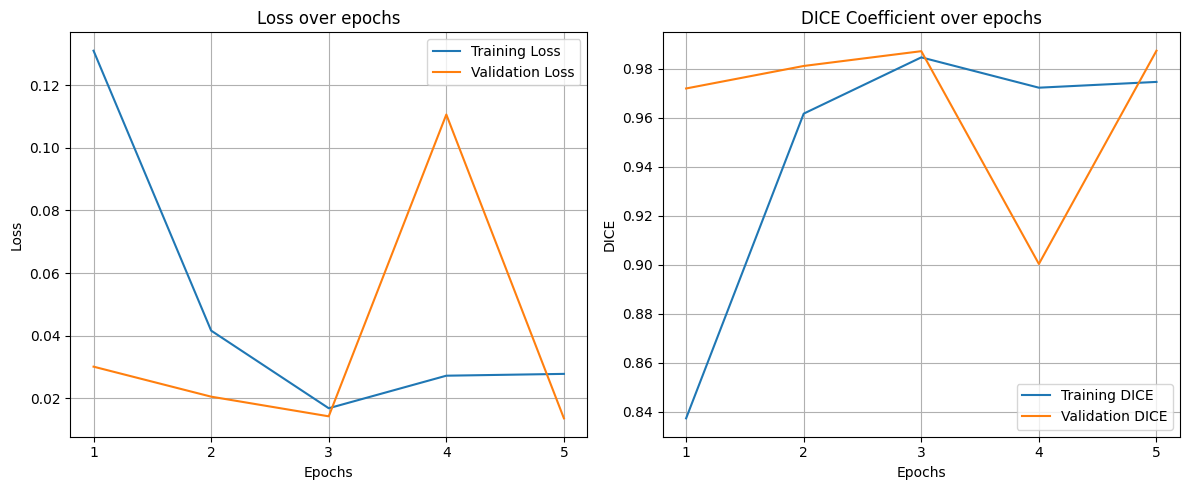

In [18]:
epochs_list = list(range(1, EPOCHS + 1))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_list, train_losses, label='Training Loss')
plt.plot(epochs_list, val_losses, label='Validation Loss')
plt.xticks(ticks=list(range(1, EPOCHS + 1, 1))) 
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid()
plt.tight_layout()

plt.legend()


plt.subplot(1, 2, 2)
plt.plot(epochs_list, train_dcs, label='Training DICE')
plt.plot(epochs_list, val_dcs, label='Validation DICE')
plt.xticks(ticks=list(range(1, EPOCHS + 1, 1)))  
plt.title('DICE Coefficient over epochs')
plt.xlabel('Epochs')
plt.ylabel('DICE')
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

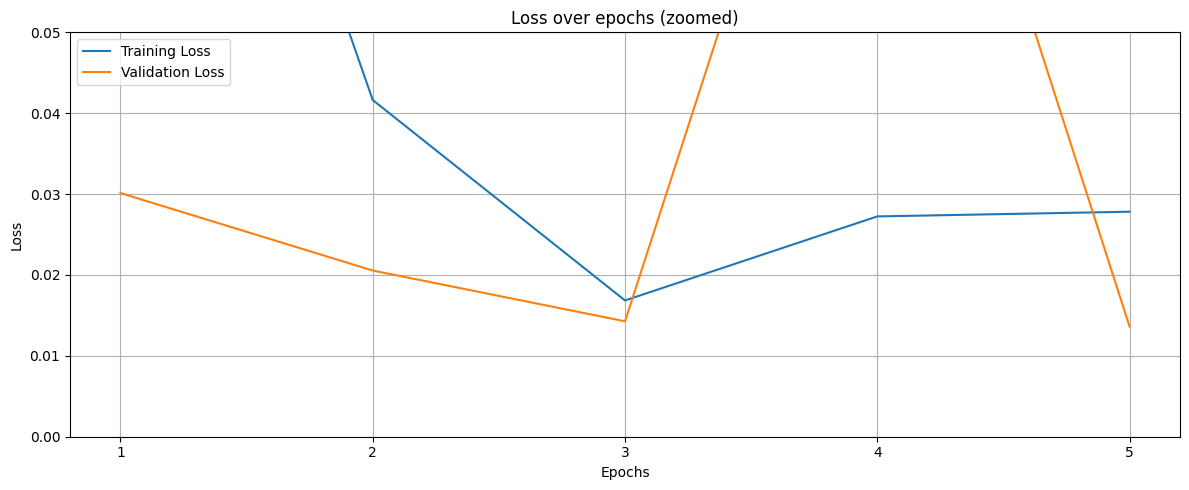

In [19]:
epochs_list = list(range(1, EPOCHS + 1))

plt.figure(figsize=(12, 5))
plt.plot(epochs_list, train_losses, label='Training Loss')
plt.plot(epochs_list, val_losses, label='Validation Loss')
plt.xticks(ticks=list(range(1, EPOCHS + 1, 1))) 
plt.ylim(0, 0.05)
plt.title('Loss over epochs (zoomed)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid()
plt.tight_layout()

plt.legend()
plt.show()

In [20]:
model_pth = '/kaggle/working/my_checkpoint.pth'
trained_model = UNet(in_channels=3, num_classes=1).to(device)
trained_model.load_state_dict(torch.load(model_pth, map_location=torch.device(device)))

<All keys matched successfully>

In [21]:
test_running_loss = 0
test_running_dc = 0

with torch.no_grad():
    for idx, img_mask in enumerate(tqdm(test_dataloader, position=0, leave=True)):
        img = img_mask[0].float().to(device)
        mask = img_mask[1].float().to(device)

        y_pred = trained_model(img)
        loss = criterion(y_pred, mask)
        dc = dice_coefficient(y_pred, mask)

        test_running_loss += loss.item()
        test_running_dc += dc.item()

    test_loss = test_running_loss / (idx + 1)
    test_dc = test_running_dc / (idx + 1)

100%|██████████| 64/64 [00:42<00:00,  1.52it/s]


In [22]:
def random_images_inference(image_tensors, mask_tensors, image_paths, model_pth, device):
    model = UNet(in_channels=3, num_classes=1).to(device)
    model.load_state_dict(torch.load(model_pth, map_location=torch.device(device)))

    transform = transforms.Compose([
        transforms.Resize((512, 512))
    ])

    # Iterate for the images, masks and paths
    for image_pth, mask_pth, image_paths in zip(image_tensors, mask_tensors, image_paths):
        # Load the image
        img = transform(image_pth)
        
        # Predict the imagen with the model
        pred_mask = model(img.unsqueeze(0))
        pred_mask = pred_mask.squeeze(0).permute(1,2,0)
        
        # Load the mask to compare
        mask = transform(mask_pth).permute(1, 2, 0).to(device)
        
        print(f"Image: {os.path.basename(image_paths)}, DICE coefficient: {round(float(dice_coefficient(pred_mask, mask)),5)}")
        
        # Show the images
        img = img.cpu().detach().permute(1, 2, 0)
        pred_mask = pred_mask.cpu().detach()
        pred_mask[pred_mask < 0] = 0
        pred_mask[pred_mask > 0] = 1
        
        plt.figure(figsize=(15, 16))
        plt.subplot(131), plt.imshow(img), plt.title("original")
        plt.subplot(132), plt.imshow(pred_mask, cmap="gray"), plt.title("predicted")
        plt.subplot(133), plt.imshow(mask, cmap="gray"), plt.title("mask")
        plt.show()

In [23]:
model_path = '/kaggle/working/my_checkpoint.pth'

random_images_inference(image_tensors, mask_tensors, image_paths, model_pàth, device="cpu")

NameError: name 'image_tensors' is not defined